# Lensing a Supernova: from Ray Shooting to the Hubble Constant

**SSP Astrophysics — Lehigh 2026**

Dr. Khakpash talked about her work using the strong graviational lensing effect
due to galaxies, more specifically micro-lensing events that can be resolved
with high-cadence surveys such as LSST, to study the sub-structure of the lenses.

When the brightness of a background, lensed sourced changes with time, we can measure
the time delays between different lensed images, and those tell use about the different
lengths traveled by light.

As a gravitational lens bends the light of objects behind
it, producing multiple images, a supernova in the background galaxy can
appear in each image at a *different time*. Refsdal's insight (1964) was that
this time delay measures the absolute scale of the Universe — the Hubble
constant $H_0$.

In this notebook you will learn how to perform such an analysis:

1. **Part A** — implement the lens deflection and the ray-shooting map
2. **Part B** — render the lensed images of a background galaxy
3. **Part C** — measure the lensing magnification
4. **Part D** — build the arrival-time (Fermat) surface and extract the time delay
5. **Part E** — combine your delay with a "monitoring campaign" to measure $H_0$

Cells marked **`# YOUR CODE HERE`** are yours to complete. Checkpoint cells
verify your work before you move on.

> **Convention:** all angles on the sky are measured in
> units of the Einstein radius, $\theta_E = 1$. Physical units (arcseconds,
> days) enter only in Part E.

## Part 0 — Setting up a synthetic system

We will use a simplified, *toy* model for this activity:

| quantity | value |
|---|---|
| lens | singular isothermal sphere (SIS), $\theta_E = 1.0''$ |
| lens redshift | $z_\ell = 0.5$ |
| source redshift | $z_s = 1.5$ |
| background | flat universe, $\Omega_m = 0.3$ |
| source | an elliptical galaxy hosting a supernova |

The lens sits at the origin of our sky coordinates. The source galaxy center
and the supernova position are set below (in units of $\theta_E$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'image.origin': 'lower', 'image.cmap': 'inferno'})

# ---- system parameters -------------------------------------------------
theta_E_arcsec = 1.0          # Einstein radius, arcseconds
z_l, z_s       = 0.5, 1.5     # lens and source redshifts
Omega_m        = 0.3          # matter density of the universe

# source-plane positions, in units of theta_E
galaxy_center = (0.45, 0.10)  # center of the background galaxy
sn_pos        = (0.40, 0.00)  # the supernova, slightly offset in its host


### Cosmological distances

As the universe expands, the distance travel by ligth, and thus the time
it takes to travel from a source (the supernova) to our telescopes, depends
on the path followed and the rate at which the universe expands. Cosmological distances 
are dimensionless functions of the redshifts times $c/H_0$. The function below computes that
dimensionless factor for the time-delay distance,

$$ D_{\Delta t} \;=\; (1+z_\ell)\,\frac{D_\ell D_s}{D_{\ell s}}
   \;=\; F(z_\ell, z_s)\,\frac{c}{H_0}, $$

so that the Hubble parameter, which measures that expansion rate, can we estimated from

$$ \boxed{\; H_0 = F(z_\ell, z_s)\,\frac{\Delta\tau}{\Delta t} \;} $$

with $\Delta\tau$ (dimensionless, from your lens model, in radians$^2$) and
$\Delta t$ (measured, in seconds). You do need to understand the implementation below including the
integral inside — it is the standard distance formula of an expanding
universe.

In [2]:
def F_lens(z_l, z_s, Omega_m=0.3):
    '''Dimensionless time-delay distance factor F, where D_dt = F * (c / H0).
    Inputs:
        z_l: lens redshift
        z_s: source redshift
        Omega_m: normalized mass energy density of the universe
    '''
    E = lambda z: np.sqrt(Omega_m*(1+z)**3 + (1-Omega_m))   # expansion rate
    dC = lambda z: np.trapezoid(1/E(np.linspace(0, z, 2048)),
                                np.linspace(0, z, 2048))    # comoving, units c/H0
    d_l  = dC(z_l)/(1+z_l)                # angular diameter distances,
    d_s  = dC(z_s)/(1+z_s)                # in units of c/H0
    d_ls = (dC(z_s)-dC(z_l))/(1+z_s)      # (valid in a flat universe)
    return (1+z_l) * d_l*d_s/d_ls

F = F_lens(z_l, z_s, Omega_m)
print(f"F(z_l={z_l}, z_s={z_s}) = {F:.4f}")


F(z_l=0.5, z_s=1.5) = 0.7775


### The background source

We use an elliptical exponential-profile galaxy (a cartoon of a real galaxy).
`source_brightness(bx, by, cx, cy)` returns the surface brightness at
source-plane position $(b_x, b_y)$ for a galaxy centered at $(c_x, c_y)$. It
is *vectorized*: feed it whole NumPy arrays of positions and it returns an
array of brightnesses, making ray-tracing efficient.

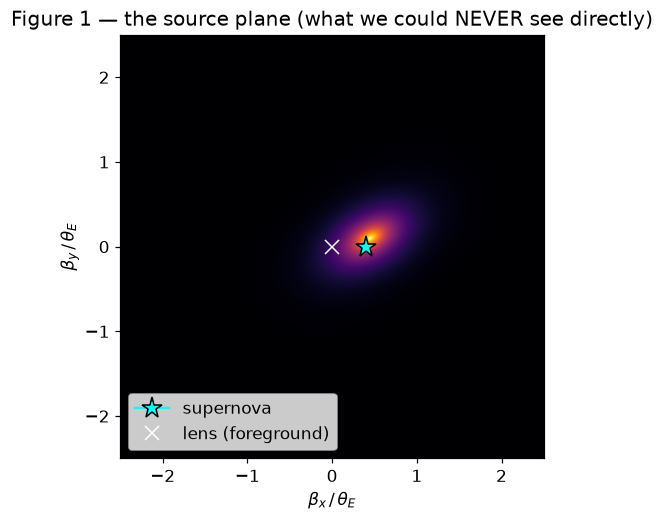

In [3]:
def source_brightness(bx, by, cx, cy, r_scale=0.30, axis_ratio=0.6, pa_deg=30.0):
    '''Elliptical exponential galaxy. Vectorized in (bx, by).
    Inputs:
        bx, by: position at which the surface brightness is returned
        cx, cy: position of the center of the galaxy
        r_scale: effective size of the galaxy 
        axis_ratio: shape of the galaxy (ellipticity)
        pa_deg: position angle for the major axis'''
    pa = np.deg2rad(pa_deg)
    dx, dy = bx - cx, by - cy
    u =  dx*np.cos(pa) + dy*np.sin(pa)       # rotate into the galaxy frame
    v = -dx*np.sin(pa) + dy*np.cos(pa)
    r_ell = np.sqrt(u**2 + (v/axis_ratio)**2)  # elliptical radius
    return np.exp(-r_ell/r_scale)

# ---- Figure 1: the unlensed truth --------------------------------------
grid_1d = np.linspace(-2.5, 2.5, 800)
BX, BY = np.meshgrid(grid_1d, grid_1d)
truth = source_brightness(BX, BY, *galaxy_center)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.imshow(truth, extent=[-2.5, 2.5, -2.5, 2.5])
ax.plot(*sn_pos, marker='*', ms=14, color='cyan', mec='k', label='supernova')
ax.plot(0, 0, 'wx', ms=9, label='lens (foreground)')
ax.set(xlabel=r'$\beta_x\,/\,\theta_E$', ylabel=r'$\beta_y\,/\,\theta_E$',
       title='Figure 1 — the source plane (what we could NEVER see directly)')
ax.legend(loc='lower left')
plt.show()


**Read Figure 1 carefully:** this is the *source plane* — the sky as it
would look with the lens magically removed. In reality the lens galaxy sits
in front (white $\times$), and every photon from this galaxy must pass its
gravitational field on the way to us. What we actually observe is what you
will now compute.

## Part A — Light deflection

The lens equation connects where
an image appears ($\boldsymbol\theta$) to where the light truly originated
($\boldsymbol\beta$):

$$ \boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta),
\qquad\text{SIS:}\quad
\boldsymbol\alpha(\boldsymbol\theta) = \theta_E\,
\frac{\boldsymbol\theta}{|\boldsymbol\theta|} $$

A singular isothermal sphere, SIS is one of the simplest models for the spatial
distribution of matter in astronomical objects such as galaxies. It is a profile
where the radial density drops with the square of the distance to the center

$$ \rho(r) \propto \frac{1}{r^2}$$

While un-physical (density diverges at the center), it is motivated by the flat 
rotational curves observed in galaxies. 
The SIS deflection has *constant magnitude* $\theta_E$ and points radially.

**Inverse ray shooting**: we do not solve for image
positions. Instead we take *every pixel* $\boldsymbol\theta$ of the camera,
apply the lens equation to find the source-plane point $\boldsymbol\beta$ it
came from, and look up the source brightness there. Multiple images appear on
their own, wherever several pixels map to the same source point.

The image-plane grid is built for you below. Note the **half-pixel offset**:
the grid is shifted so no pixel sits exactly at $\boldsymbol\theta = 0$,
where $\boldsymbol\theta/|\boldsymbol\theta|$ would divide by zero.

In [4]:
# ---- image-plane grid ----------------------------------------
N_pix, half_width = 800, 2.5
step = 2*half_width/N_pix
theta_1d = np.linspace(-half_width, half_width, N_pix, endpoint=False) + step/2
TX, TY = np.meshgrid(theta_1d, theta_1d)     # theta_x, theta_y at every pixel
print(f"grid: {N_pix}x{N_pix} pixels, spacing {step:.4f} theta_E,"
      f" closest approach to origin {np.hypot(TX,TY).min():.4f}")


grid: 800x800 pixels, spacing 0.0063 theta_E, closest approach to origin 0.0044


### EXERCISE 1 — the SIS deflection

Write `alpha_sis(tx, ty)` returning the two components
$(\alpha_x, \alpha_y) = \theta_E\,(\theta_x, \theta_y)/|\boldsymbol\theta|$.
Remember $\theta_E = 1$ in our units, and that `tx, ty` are full arrays.

In [5]:
def alpha_sis(tx, ty):
    '''SIS deflection angle, units of theta_E. Returns (alpha_x, alpha_y).'''
    ### BEGIN SOLUTION

    ### END SOLUTION


### EXERCISE 2 — shoot the rays

Apply the lens equation on the whole grid: compute the source-plane arrays
`BX_ray, BY_ray` telling us, for each pixel, where its light originated.

In [6]:
### BEGIN SOLUTION

### END SOLUTION


### ✅ Checkpoint A *(run it!)*

An SIS with a source at $\beta = 0.4$ on the $x$-axis has
images at $\theta_\pm = \beta \pm \theta_E$, i.e. at $+1.4$ and $-0.6$. So a
ray observed at $\boldsymbol\theta = (1.4, 0)$ must trace back to
$\boldsymbol\beta = (0.4, 0)$, and one at $(-0.6, 0)$ must trace back to the
same point. The cell checks your map at (interpolated) grid positions.

In [7]:
def _lookup(BX_ray, BY_ray, tx, ty, theta_1d):
    i = np.argmin(np.abs(theta_1d - ty)); j = np.argmin(np.abs(theta_1d - tx))
    return BX_ray[i, j], BY_ray[i, j]

ok = True
for (tx, ty), (bx_true, by_true) in [((1.4, 0.0), (0.4, 0.0)),
                                     ((-0.6, 0.0), (0.4, 0.0)),
                                     ((0.0, 2.0), (0.0, 1.0))]:
    bx, by = _lookup(BX_ray, BY_ray, tx, ty, theta_1d)
    good = np.hypot(bx - bx_true, by - by_true) < 2*step
    ok &= good
    print(f"ray at theta=({tx:+.1f},{ty:+.1f}) -> beta=({bx:+.3f},{by:+.3f})"
          f"   expected ({bx_true:+.1f},{by_true:+.1f})   {'PASS' if good else 'FAIL'}")
print("\nCheckpoint A:", "PASSED — your lens works." if ok else
      "FAILED — hint: if signs look flipped, re-read trap 3 in notes Sec. 6"
      " (did you write theta + alpha?).")
assert ok


NameError: name 'BX_ray' is not defined

## Part B — Render the lensed galaxy

You have a map from every camera pixel to its origin on the source plane.
To render the lensed sky, evaluate the source brightness at the mapped positions.

### EXERCISE — paint the image

Fill `lensed` with the brightness of the source galaxy as seen through the
lens. Use `source_brightness`, the ray-shot coordinates from GAP 2, and the
galaxy center from Part 0.

In [ ]:
### BEGIN SOLUTION

### END SOLUTION

# ---- Figure 2: source plane vs image plane (provided) -------------------
fig, axes = plt.subplots(1, 2, figsize=(10.4, 5))
axes[0].imshow(truth, extent=[-2.5, 2.5, -2.5, 2.5])
axes[0].set_title('source plane (unobservable truth)')
axes[1].imshow(lensed, extent=[-2.5, 2.5, -2.5, 2.5])
ring = plt.Circle((0, 0), 1.0, fill=False, ls='--', color='cyan', lw=1.2)
axes[1].add_patch(ring)
axes[1].set_title('image plane (what the telescope sees)')
for ax in axes:
    ax.set(xlabel=r'$x\,/\,\theta_E$', ylabel=r'$y\,/\,\theta_E$')
fig.suptitle('Figure 2 — gravitational lensing by an SIS'
             '  (dashed: Einstein ring)', y=1.02)
plt.show()


**Interpret the image.** The galaxy is imaged twice: a bright,
stretched arc outside the Einstein ring and a fainter, inverted counter-image
inside it. Every photon in both images left the *same* galaxy.

### A tour in $\beta$

The loop below moves the galaxy from dead center to well outside the
Einstein radius. Watch the sequence of morphologies from the lecture: ring →
arcs → double → single.

Feel free to explore what happens when you change the $\beta$ parameter to other values

In [ ]:
betas = [0.0, 0.4, 0.8, 1.5]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, b in zip(axes, betas):
    img = source_brightness(BX_ray, BY_ray, b, 0.0)
    ax.imshow(img, extent=[-2.5, 2.5, -2.5, 2.5])
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls='--', color='cyan', lw=1))
    ax.set_title(fr'$\beta = {b}\,\theta_E$')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(r'Figure 3 — morphology vs source position: ring $\to$ arcs'
             r' $\to$ double $\to$ single', y=1.04)
plt.show()


### ✍️ Question 1 *(markdown — answer in this cell)*

In two or three sentences: what happens to the number and shape of the
images as $\beta$ crosses $\theta_E$? Why is $\theta_E$ the natural
boundary between "strongly lensed" and "barely perturbed"? (Notes, Sec. 3.3.)

**Answer:**
*(Master key: for $\beta<\theta_E$ the SIS produces two images straddling the
lens, merging into arcs and finally a full Einstein ring as
$\beta \to 0$; at $\beta=\theta_E$ the inner image reaches the lens center
with vanishing flux and disappears, so for $\beta>\theta_E$ a single, mildly
sheared image remains. $\theta_E$ marks the boundary because it is where the
inner solution $\theta_-=\beta-\theta_E$ ceases to exist.)*

### ⭐ EXERCISE 4: point-mass lens

A point mass deflects as
$\boldsymbol\alpha = \theta_E^2\,\boldsymbol\theta/|\boldsymbol\theta|^2$.
Write it, re-render Figure 2, and note the key difference: the point mass
**never** loses its second image (the lecture's quadratic always has two
roots).

The point mass model is better suited for compact objects, such as stars of
black holes. You can place a population of point masses embedded in a SIS to 
study, for example, micro-lensing events due to halo stars in the lensing 
galaxy.

In [ ]:
def alpha_point(tx, ty):
    '''Point-mass deflection, units of theta_E.'''
    ### BEGIN SOLUTION

    ### END SOLUTION

APX, APY = alpha_point(TX, TY)
lensed_pm = source_brightness(TX - APX, TY - APY, *galaxy_center)
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.imshow(lensed_pm, extent=[-2.5, 2.5, -2.5, 2.5])
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls='--', color='cyan', lw=1.2))
ax.set(title='Stretch — same galaxy, point-mass lens',
       xlabel=r'$x/\theta_E$', ylabel=r'$y/\theta_E$')
plt.show()


In [ ]:
# ---- point-mass morphology tour: the counter-image never disappears ----
APX, APY = alpha_point(TX, TY)
BX_pm, BY_pm = TX - APX, TY - APY          # ray-shot map, point-mass lens

betas = [0.0, 0.4, 0.8, 1.5, 2.0]
fig, axes = plt.subplots(1, len(betas), figsize=(3.5*len(betas), 3.8))
for ax, b in zip(axes, betas):
    img = source_brightness(BX_pm, BY_pm, b, 0.0)
    ax.imshow(img, extent=[-2.5, 2.5, -2.5, 2.5])
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls='--', color='cyan', lw=1))
    # analytic image positions of the galaxy center, for reference
    th_p = 0.5*(b + np.sqrt(b**2 + 4))
    th_m = 0.5*(b - np.sqrt(b**2 + 4))
    ax.plot([th_p, th_m], [0, 0], '+', color='lime', ms=8, mew=1.5)
    ax.set_title(fr'$\beta = {b}\,\theta_E$' + f'\n' +
                 fr'$\theta_-$ = {th_m:+.2f}$\,\theta_E$', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Point-mass lens: the counter-image survives at every $\\beta$'
             ' (green: analytic $\\theta_\\pm$ of the galaxy center)', y=1.06)
plt.show()

## Part C — Magnification

Lensing conserves surface brightness but changes the *area* a source covers
on the sky, so it changes total flux: images are **magnified**. This is why
lensed supernovae at $z\sim1.5$ are findable at all, and it is the quantity
the guest speaker's stellar *microlensing* perturbs image by image.

Measuring it on your grid does not require additional calculus: render a
small test source **with and without the lens** on the same pixel grid, and
compare total (summed) fluxes.

### EXERCISE 5 — measure the magnification

Complete `magnification(b)`: total flux of the lensed rendering divided by
total flux of the unlensed rendering, for a compact circular test source
centered at $(b, 0)$.

In [ ]:
def test_source(bx, by, cx, cy, r_src=0.08):
    '''Small circular Gaussian test source. [Provided]'''
    return np.exp(-((bx-cx)**2 + (by-cy)**2)/(2*r_src**2))


def magnification(b, TX, TY, BX_ray, BY_ray):
    '''Total magnification of a compact source at (b, 0), measured on the
    given image-plane grid and its ray-shot map.'''
    ### BEGIN SOLUTION

    ### END SOLUTION


# ---- dedicated wide grid for photometry (image at theta+ = beta + 1
#      would fall off the +/-2.5 rendering frame for beta > ~1.4) --------
hw_C, N_C = 4.0, 1280                     # same pixel scale as main grid
step_C = 2*hw_C/N_C
tC = np.linspace(-hw_C, hw_C, N_C, endpoint=False) + step_C/2
TXC, TYC = np.meshgrid(tC, tC)
rC = np.hypot(TXC, TYC)
BXC, BYC = TXC - TXC/rC, TYC - TYC/rC


# ---- Figure 4: magnification vs source position --------------
b_vals = np.linspace(0.15, 2.0, 25)
mu_measured = [magnification(b, TXC, TYC, BXC, BYC) for b in b_vals]

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(b_vals, mu_measured, 'o', label='your grid measurement')
b_th = np.linspace(0.15, 2.0, 300)
mu_th = np.where(b_th < 1, 2/b_th, 1 + 1/b_th)   # SIS analytic total magnification
ax.plot(b_th, mu_th, '-', color='crimson', label='SIS analytic')
ax.axvline(1.0, ls=':', color='gray')
ax.set(xlabel=r'source position $\beta\,/\,\theta_E$',
       ylabel=r'total magnification $\mu$',
       title='Figure 4 — magnification diverges as the source approaches the axis')
ax.legend()
plt.show()


**Interpreting the figure.** As $\beta \to 0$ the total magnification
diverges as $2/\beta$ (grid points should follow the red curve; the small
departure at the smallest $\beta$ is the finite size of the test source —
real sources cap the divergence the same way). Two consequences worth
keeping:

- Lensing acts as a **natural telescope**: SN Refsdal's images were magnified
  by factors of several to $\sim$20, which is why a $z=1.49$ supernova was
  observable at all.
- Anything that perturbs the deflection locally — like the individual
  **stars** of the lens galaxy — perturbs $\mu$ image by image. That is the
  microlensing "noise" on quasar light curves from the guest lecture, and a
  major reason supernovae (one-shot, known light-curve shape) are cleaner
  delay clocks than quasars.

## Part D — The Fermat surface and the time delay

The arrival time of light from
source-plane position $\boldsymbol\beta$ via image-plane direction
$\boldsymbol\theta$ is

$$ t(\boldsymbol\theta) = \frac{D_{\Delta t}}{c}\,\tau(\boldsymbol\theta),
\qquad
\tau(\boldsymbol\theta) = \underbrace{\tfrac12\,
|\boldsymbol\theta - \boldsymbol\beta|^2}_{\text{geometric (longer path)}}
\;-\; \underbrace{\psi(\boldsymbol\theta)}_{\text{Shapiro (slow clocks)}} ,
\qquad \psi_{\rm SIS} = \theta_E\,|\boldsymbol\theta| . $$

**Images form at the stationary points of $\tau$** — that statement *is* the
lens equation ($\nabla\tau = 0 \Leftrightarrow
\boldsymbol\beta = \boldsymbol\theta - \nabla\psi$). So instead of solving
for image positions, we will *plot the surface and read them off*: a minimum
(the image that arrives first) and a saddle (the delayed one). The supernova
is our point source: from here on, $\boldsymbol\beta = $ `sn_pos`.

### EXERCISE 6 — the lens potential and EXERCISE 7 — the Fermat potential

In [ ]:
def psi_sis(tx, ty):
    '''SIS lens potential, psi = theta_E * |theta| (theta_E = 1).'''
    ### BEGIN SOLUTION

    ### END SOLUTION

def tau(tx, ty, bx, by):
    '''Dimensionless Fermat potential: geometric term minus lens potential.'''
    ### BEGIN SOLUTION

    ### END SOLUTION


### Locating the stationary points on the grid

`find_min_and_saddle` finds the two images without any root-solving, using
only the grid (read the comments):

- the **minimum** is simply the global `argmin` of $\tau$;
- the **saddle** is found as the point where the *gradient magnitude*
  $|\nabla\tau|$ (computed with `np.gradient`) is smallest, after masking out
  (i) the neighborhood of the minimum we already found and (ii) the central
  cusp at the lens position, where $\tau$ is not smooth.

In [ ]:
def find_min_and_saddle(TAU, TX, TY, step, exclude_r=0.15):
    '''Return (theta_min, theta_saddle) as (x, y) tuples, from the grid.'''
    R = np.hypot(TX, TY)
    # --- minimum: global argmin -----------------------------------------
    i0, j0 = np.unravel_index(np.argmin(TAU), TAU.shape)
    th_min = (TX[i0, j0], TY[i0, j0])
    # --- saddle: smallest |grad tau| away from the min and the cusp ------
    gy, gx = np.gradient(TAU, step)               # d(tau)/dy, d(tau)/dx
    gradmag = np.hypot(gx, gy)
    mask = (np.hypot(TX - th_min[0], TY - th_min[1]) > exclude_r) & (R > exclude_r)
    gradmag_masked = np.where(mask, gradmag, np.inf)
    i1, j1 = np.unravel_index(np.argmin(gradmag_masked), TAU.shape)
    th_sad = (TX[i1, j1], TY[i1, j1])
    return th_min, th_sad

TAU = tau(TX, TY, *sn_pos)
th_min, th_sad = find_min_and_saddle(TAU, TX, TY, step)
print(f"minimum at ({th_min[0]:+.3f}, {th_min[1]:+.3f})   "
      f"saddle at ({th_sad[0]:+.3f}, {th_sad[1]:+.3f})")

# ---- Figure 5: the arrival-time surface (provided) ----------------------
fig, ax = plt.subplots(figsize=(6.6, 5.6))
cs = ax.contour(TX, TY, TAU, levels=25, cmap='viridis')
ax.clabel(cs, cs.levels[::5], fontsize=7, fmt='%.2f')
ax.plot(*th_min, 'o', color='red', ms=8, label='minimum (first image)')
ax.plot(*th_sad, 's', color='red', ms=7, label='saddle (delayed image)')
ax.plot(*sn_pos, '+', color='blue', ms=11, mew=2, label='SN true position')
ax.plot(0, 0, 'kx', ms=9, label='lens')
ax.set(xlabel=r'$\theta_x/\theta_E$', ylabel=r'$\theta_y/\theta_E$',
       title=r'Figure 5 — arrival-time surface $\tau(\boldsymbol{\theta})$'
             ' for the supernova', aspect='equal')
ax.legend(loc='lower left', fontsize=9)
plt.show()


The saddle image is the *late* one — its
light takes longer to arrive.

### EXERCISE 8 — the dimensionless delay

Compute `dtau`, the Fermat-potential difference between the saddle (late) and
the minimum (early) image, `tau(saddle) - tau(minimum)`.

In [ ]:
### BEGIN SOLUTION

### END SOLUTION
print(f"dtau = {dtau:.4f}  (units of theta_E^2)")


### ✅ Checkpoint D *(run it!)*

The lecture derived a closed form for the SIS delay
(notes, Eq. 21): for a source on-axis at distance $\beta$,

$$ \Delta\tau = 2\,\theta_E\,\beta . $$

Our supernova sits at $\beta = 0.4$ on the axis, so your grid must give
$\Delta\tau \approx 0.8$. Here, lecture math and your code meet.

In [ ]:
beta_sn = np.hypot(*sn_pos)
dtau_analytic = 2.0*beta_sn
print(f"grid:     dtau = {dtau:.4f}")
print(f"analytic: dtau = {dtau_analytic:.4f}   (= 2 * beta)")
ok = abs(dtau - dtau_analytic) < 0.01
print("\nCheckpoint D:", "PASSED — you have a time delay." if ok else
      "FAILED — hints: is the geometric term (theta - beta), not (theta + beta)?"
      " Did psi get the minus sign in tau?")
assert ok


## Part E — Measure the Hubble constant

$\Delta\tau$ is pure geometry — it knows nothing about how big the
Universe is. The *measured* delay in days does. Combining them:

$$ \Delta t = \frac{D_{\Delta t}}{c}\,\Delta\tau,
\qquad D_{\Delta t} = F\,\frac{c}{H_0}
\qquad\Longrightarrow\qquad
\boxed{\,H_0 = F\,\frac{\Delta\tau}{\Delta t}\,} $$

**The monitoring campaign** *(synthetic)*: imagine your team was
awarded the follow-up time. The photometry pipeline reports that the
supernova appeared in the saddle image

$$ \Delta t_{\rm obs} = 75.1 \pm 3.0 \ \text{days} $$

after the minimum image.

One unit subtlety: `dtau` is in units of
$\theta_E^2$; the boxed formula needs it in **radians$^2$** (that is where
the physical size $\theta_E = 1.0''$ finally enters), and $\Delta t$ in
seconds.

### EXERCISE 9 — the measurement

Convert, apply the boxed formula, and express $H_0$ in km/s/Mpc
(1 Mpc $= 3.0857\times10^{19}$ km).

In [ ]:
dt_obs_days, dt_obs_err = 75.1, 3.0          # the "campaign" measurement
arcsec_to_rad = np.pi/180/3600
Mpc_km        = 3.0857e19                     # km in one megaparsec

### BEGIN SOLUTION

### END SOLUTION
print(f"H0 = {H0:.1f} km/s/Mpc")


### EXERCISE 10 — the error bar

$H_0 \propto 1/\Delta t$, so to first order the relative errors match:
$\sigma_{H_0}/H_0 = \sigma_{\Delta t}/\Delta t$.

In [ ]:
### BEGIN SOLUTION

### END SOLUTION
print(f"H0 = {H0:.1f} +/- {H0_err:.1f} km/s/Mpc   "
      f"({100*H0_err/H0:.1f}% measurement)")


### Figure 6: your measurement, dropped onto the Hubble tension

In [ ]:
published = [
    ('Planck 2018 (CMB)',            67.4, 0.5, 0.5),
    ('SH0ES 2022 (Cepheids+SNe)',    73.0, 1.0, 1.0),
    ('TDCOSMO 2025 (lensed quasars)',71.6, 3.3, 3.9),
    ('SN Refsdal 2023 (cluster SN)', 66.6, 3.3, 4.1),
]
fig, ax = plt.subplots(figsize=(7.6, 3.6))
for k, (label, h, lo, hi) in enumerate(published):
    ax.errorbar(h, k, xerr=[[lo], [hi]], fmt='o', color='steelblue', capsize=3)
    ax.text(h, k + 0.22, label, ha='center', fontsize=9)
ax.axvspan(H0 - H0_err, H0 + H0_err, color='crimson', alpha=0.18)
ax.axvline(H0, color='crimson', lw=1.5)
ax.text(H0, len(published) - 0.25, 'YOUR team', color='crimson',
        ha='center', fontweight='bold')
ax.set(xlabel=r'$H_0$  [km s$^{-1}$ Mpc$^{-1}$]', yticks=[],
       xlim=(60, 80), ylim=(-0.6, len(published)),
       title='Figure 6 — the Hubble tension, with your measurement')
plt.show()


### ✍️ Question 2 *(answer in this cell)*

This error bar is a few percent — competitive with the professional literature. Yet
something important separates your measurement from theirs: what did we
**assume** rather than measure? What observable would you add to test that
assumption?

**Answer:**
*(Master key: we assumed the lens is an SIS — the mass profile was an input,
not a measurement. Profiles of different steepness reproduce the same image
positions but predict different delays (the mass-sheet degeneracy), so real
error budgets are dominated by profile uncertainty. The standard extra
observable is stellar kinematics of the lens galaxy — a velocity dispersion
profile — which pins down the mass distribution independently of lensing.)*

---

## Where to go from here

- **The original method paper**: https://articles.adsabs.harvard.edu/pdf/1964MNRAS.128..307R
- **The reappearance of the supernova**: https://iopscience.iop.org/article/10.3847/2041-8205/819/1/L8/pdf
- **The application to the determination to H0**: https://www.science.org/doi/epdf/10.1126/science.abh1322
- **A related paper to better understand the method**: https://iopscience.iop.org/article/10.3847/1538-4357/aac2c9/pdf

## Appendix — interactive $\beta$ slider

Requires `ipywidgets`; the notebook is complete without it. Everything here
reuses functions you already wrote — read how little extra code interactivity
costs once the physics is vectorized.

In [ ]:
try:
    from ipywidgets import interact, FloatSlider
    def show(beta=0.4):
        img = source_brightness(BX_ray, BY_ray, beta, 0.0)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(img, extent=[-2.5, 2.5, -2.5, 2.5])
        ax.add_patch(plt.Circle((0, 0), 1, fill=False, ls='--', color='cyan'))
        ax.set(title=fr'$\beta = {beta:.2f}\,\theta_E$',
               xlabel=r'$x/\theta_E$', ylabel=r'$y/\theta_E$')
        plt.show()
    interact(show, beta=FloatSlider(min=0.0, max=2.0, step=0.05, value=0.4))
except ImportError:
    print("ipywidgets not installed — skip (optional demo cell).")


## Appendix — complex lenses

In the weak field, the effects combine linearly

In [ ]:
cluster = [                    # (x_i, y_i, theta_E_i), units of theta_E
    ( 0.00,  0.00, 0.90),      # brightest cluster galaxy
    (-0.85,  0.55, 0.45),
    ( 0.70, -0.65, 0.40),
    ( 0.15,  0.95, 0.30),
]

def alpha_cluster(tx, ty, members):
    '''Total deflection of a group of SIS halos (superposition).'''
    ### BEGIN SOLUTION
    ax_tot, ay_tot = np.zeros_like(tx), np.zeros_like(ty)
    for (xi, yi, tEi) in members:
        axi, ayi = alpha_sis(tx - xi, ty - yi)   # your own SIS, recentered
        ax_tot += tEi*axi
        ay_tot += tEi*ayi
    return ax_tot, ay_tot
    ### END SOLUTION

AXc, AYc = alpha_cluster(TX, TY, cluster)
img_cluster = source_brightness(TX - AXc, TY - AYc, 0.25, 0.10, r_scale=0.20)


# ---- Figure 7 (provided): one halo vs a cluster of halos ----------------
src_kw = dict(cx=0.25, cy=0.10, r_scale=0.20)   # same source in both panels

# single SIS comparison (reuses your Part A machinery)
AX1, AY1 = alpha_sis(TX, TY)
img_single = source_brightness(TX - AX1, TY - AY1, **src_kw)

# cluster render (from the previous cell)
img_cluster = source_brightness(TX - AXc, TY - AYc, **src_kw)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5))

axes[0].imshow(img_single, extent=[-2.5, 2.5, -2.5, 2.5])
axes[0].add_patch(plt.Circle((0, 0), 1.0, fill=False, ls='--',
                             color='cyan', lw=1.2))
axes[0].set_title('one SIS halo (dashed: its Einstein ring)')

axes[1].imshow(img_cluster, extent=[-2.5, 2.5, -2.5, 2.5])
for (xi, yi, tEi) in cluster:
    axes[1].add_patch(plt.Circle((xi, yi), 0.07, fill=False,
                                 color='cyan', lw=1.2))
    axes[1].add_patch(plt.Circle((xi, yi), tEi, fill=False, ls=':',
                                 color='cyan', lw=0.7, alpha=0.5))
axes[1].set_title('4-halo "cluster"\n'
                  '(circles: member galaxies; dotted: their $\\theta_{E,i}$)')

for ax in axes:
    ax.set(xlabel=r'$x\,/\,\theta_E$', ylabel=r'$y\,/\,\theta_E$')
fig.suptitle('Figure 7 — same source, more complicated lens: '
             'giant arcs and extra images', y=1.02)
plt.show()